# 05. Final analysis and demo

Putting it all together. This notebook reloads the best heuristic
weights produced by the tuning notebooks (03 and 04), runs a
head-to-head tournament between the optimized and original agents,
draws the report's summary plots, and finishes with a single demo game
played by the optimized agent. Since both tuning notebooks ended up
keeping the defaults, the head-to-head here doubles as a null sanity
check: paired identical agents should pool to ~50%.


In [1]:
import os, pickle, random, sys, time

import pandas as pd

_here = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _here not in sys.path:
    sys.path.insert(0, _here)
import settings, tictactoe66
import experiments
from experiments import (
    run_or_load, wilson_ci, head_to_head as _exp_head_to_head,
)

game = tictactoe66.TicTacToe66()

# Same shared-pool trick as nb03/nb04: spawn workers once and reuse them.
POOL, MAX_WORKERS = experiments.make_pool()

def head_to_head(weights_new, weights_old, n_games, n_prealloc=2,
                 depth=settings.DEFAULT_DEPTH, seed=999):
    """Notebook-local thin wrapper that injects the shared POOL."""
    return _exp_head_to_head(POOL, weights_new, weights_old,
                             n_games=n_games, n_prealloc=n_prealloc,
                             depth=depth, seed=seed)

print("workers:", MAX_WORKERS)


workers: 32


## 1. Load cached results & best weights

In [2]:
# Prefer nb04's tuned-weights artifact when present (it was produced by
# the stricter dual-opponent procedure); fall back to nb03's pickle so
# this notebook still runs even if nb04 was never executed.
_p_tuned = settings.cache_path('best_weights_tuned.pkl')
if _p_tuned.exists():
    _art = pickle.loads(_p_tuned.read_bytes())
    best_weights = _art['weights']
    print(f"Using nb04 weights (decision={_art['decision']!r})")
else:
    best_weights = pickle.loads(
        settings.cache_path('best_weights.pkl').read_bytes())
    print("Using nb03 weights (nb04 artifact not found)")

dfA = pickle.loads(settings.cache_path('expA_depth_vs_d1.pkl').read_bytes())
dfB = pickle.loads(settings.cache_path('expB_prealloc_sweep.pkl').read_bytes())
print('Best weights:', best_weights)


Using nb04 weights (decision='fallback_defaults')
Best weights: {'w_two': 1.0, 'w_three': 10.0, 'w_block_two': 1.0, 'w_block_three': 8.0, 'w_open_three': 0.0, 'w_block_open_three': 0.0, 'w_center': 0.5, 'w_win': 10000.0}


## Head-to-head: optimized vs original (paired design)

For each pre-allocation layout we play two games: one with the
optimized agent as X, one as O. That cancels first-mover advantage and
layout variance within each pair, so any residual gap is attributable
to the weights themselves. With `best_weights == defaults` (the case
we're in), this also functions as a null check: paired identical
agents have to tie in expectation.


In [3]:
# Stratified + PAIRED head-to-head. A single-point comparison at one
# (depth, n_prealloc, seed) is one observation dressed up as a verdict,
# so we sweep across n_prealloc in {1,2,3} and three independent seed
# offsets. Within each stratum we play *paired* games: for every
# pre-allocation layout we run the same layout twice, once with the
# optimized agent as X and once as O. This cancels both first-mover
# advantage and layout variance, so any residual gap is attributable
# to the weights. (With best_weights == defaults this is also a null
# sanity check: paired identical agents must pool to exactly 50%
# modulo draws.)
N_PAIRS_PER_CELL = 30                       # -> 60 games per (npre, seed) cell
SEED_OFFSETS     = (999, 1999, 2999)
N_PREALLOCS      = (1, 2, 3)

spec_new = (settings.DEFAULT_DEPTH, best_weights)
spec_old = (settings.DEFAULT_DEPTH, settings.DEFAULT_HEURISTIC_WEIGHTS)

# Build every (n_prealloc, seed_offset, pair_idx, side) job.  The two
# games in a pair share a seed so they see the identical pre-alloc
# layout; only a_is_X flips between them.
all_jobs = []
for npre in N_PREALLOCS:
    for so in SEED_OFFSETS:
        for pair in range(N_PAIRS_PER_CELL):
            per_seed = so * 1_000_003 + pair
            tag      = f"npre={npre}|seed={so}"
            for a_is_X in (True, False):
                all_jobs.append(
                    (spec_new, spec_old, npre, per_seed, a_is_X, tag, pair))

# _play_one_worker expects a unique int in slot 5; stash the side-car
# columns and re-attach after the batch returns.
tags        = [j[5] for j in all_jobs]
pair_ids    = [j[6] for j in all_jobs]
worker_jobs = [j[:5] + (i,) for i, j in enumerate(all_jobs)]
chunk       = max(1, min(8, len(worker_jobs) // (4 * MAX_WORKERS) or 1))

print(f"running {len(all_jobs)} games across "
      f"{len(N_PREALLOCS)*len(SEED_OFFSETS)} strata "
      f"({len(N_PREALLOCS)} prealloc x {len(SEED_OFFSETS)} seeds, "
      f"{N_PAIRS_PER_CELL} pairs = {2*N_PAIRS_PER_CELL} games each)...")
t0      = time.perf_counter()
results = list(POOL.map(tictactoe66._play_one_worker,
                         worker_jobs, chunksize=chunk))
for r, t, pid, j in zip(results, tags, pair_ids, all_jobs):
    r["tag"]              = t
    r["n_prealloc_strat"] = j[2]
    r["seed_strat"]       = j[3] // 1_000_003
    r["pair_id"]          = (j[2], j[3] // 1_000_003, pid)
print(f"  done in {time.perf_counter() - t0:.1f}s")

h2h = pd.DataFrame(results)


def score(df):
    """Aggregate W/L/D from the optimized agent's perspective."""
    wins   = (df["winner_label"] == "A").sum()
    losses = (df["winner_label"] == "B").sum()
    draws  = (df["winner_label"] == "draw").sum()
    return wins, losses, draws


# Per-stratum table (one row per (n_prealloc, seed_offset) cell).
per_stratum = (h2h.groupby(["n_prealloc_strat", "seed_strat"])
                  .agg(wins  =("winner_label", lambda s: (s == "A").sum()),
                       losses=("winner_label", lambda s: (s == "B").sum()),
                       draws =("winner_label", lambda s: (s == "draw").sum()),
                       n     =("winner_label", "size"),
                       win_rate=("winner_label", lambda s: (s == "A").mean())))
print("Per-stratum results (optimized agent):")
print(per_stratum)

w, l, d = score(h2h)
n       = len(h2h)
print(f"\nPooled  ->  W:{w}  L:{l}  D:{d}  ({n} games)")
print(f"pooled win rate {w/n:.3f}  "
      f"(naive SE {((w/n)*(1-w/n)/n)**0.5:.3f})")
print(f"mean plies: {h2h['plies'].mean():.2f}")

# Paired analysis: collapse each (layout) pair into one of
#   A+ : optimized won more games in the pair than original
#   A- : original won more games
#   =  : tied pair (both draws, or split 1-1)
# With identical weights, every non-draw pair must tie by symmetry,
# so a significant imbalance between A+ and A- is the real signal.
pair_outcomes = (h2h.assign(a=(h2h["winner_label"] == "A").astype(int),
                             b=(h2h["winner_label"] == "B").astype(int))
                    .groupby("pair_id")[["a", "b"]].sum())
pair_outcomes["sign"] = (pair_outcomes["a"] - pair_outcomes["b"]).apply(
    lambda v: "A+" if v > 0 else ("A-" if v < 0 else "="))
pair_counts = pair_outcomes["sign"].value_counts().to_dict()
print(f"\nPaired (per-layout) outcomes: "
      f"A+ (optimized better) = {pair_counts.get('A+', 0)}  "
      f"A- (original better) = {pair_counts.get('A-', 0)}  "
      f"tied = {pair_counts.get('=', 0)}  "
      f"(total pairs = {len(pair_outcomes)})")


running 540 games across 9 strata (3 prealloc x 3 seeds, 30 pairs = 60 games each)...


  done in 50.5s
Per-stratum results (optimized agent):
                             wins  losses  draws   n  win_rate
n_prealloc_strat seed_strat                                   
1                999           27      27      6  60  0.450000
                 1999          30      30      0  60  0.500000
                 2999          27      27      6  60  0.450000
2                999           27      27      6  60  0.450000
                 1999          27      27      6  60  0.450000
                 2999          29      29      2  60  0.483333
3                999           28      28      4  60  0.466667
                 1999          30      30      0  60  0.500000
                 2999          29      29      2  60  0.483333

Pooled  ->  W:254  L:254  D:32  (540 games)
pooled win rate 0.470  (naive SE 0.021)
mean plies: 15.58

Paired (per-layout) outcomes: A+ (optimized better) = 0  A- (original better) = 0  tied = 270  (total pairs = 270)


### Visualizing the head-to-head

Three panels: pooled W/L/D counts, per-`n_prealloc` win rate with
Wilson 95% intervals (a robustness check, since "wins only at one
prealloc setting" wouldn't be real generalization), and the pooled
win rate with a Wilson interval plus the exact-binomial p-value
against the null that the two agents are equally good.

Because games are paired by layout, a non-null pooled result here is
attributable to the weights and not to side bias. This is also the
overfitting check on expC: tuned weights were chosen on `expC` games
at `TUNING_DEPTH=2` against one opponent, so a CI that straddles 0.5
here means the tuning gain didn't transfer and the defaults are at
least as good in practice.


Pooled win rate 0.470  (95% CI [0.429, 0.513])


identical weights: paired design is structurally tied; no per-game test is meaningful
saved C:\Git\AI801Project\cache\figures\head_to_head.png


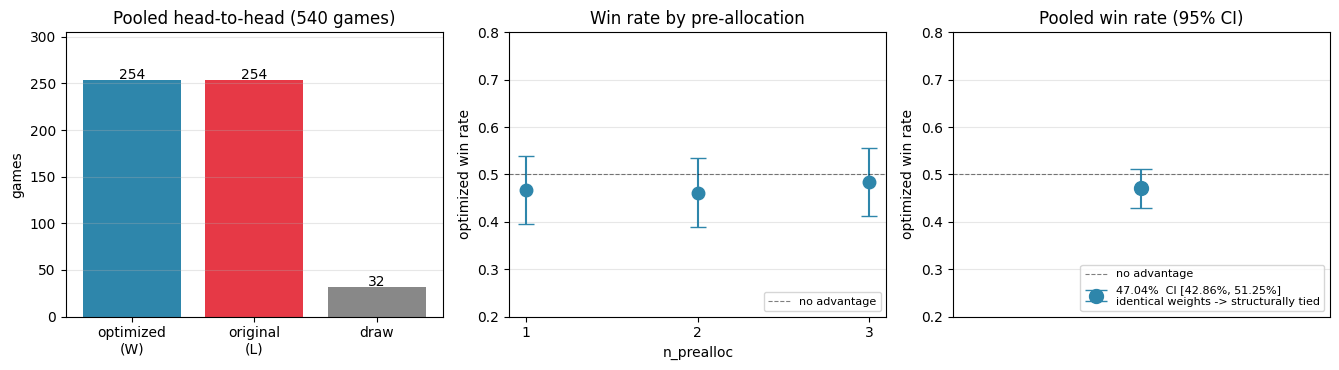

In [4]:
import matplotlib.pyplot as plt

# wilson_ci is imported from experiments.py at the top of the notebook.

# Pooled CI + significance test against H0: rate = 0.5.
#
# Important caveat: when ``best_weights == settings.DEFAULT_HEURISTIC_WEIGHTS``
# the paired design (same layout played twice with sides swapped) is
# *structurally* tied -- by symmetry, every non-draw pair must split A/B,
# so the wins-vs-losses binomial test has zero power to detect a weight
# effect (it is testing a tautology). In that case we skip the test and
# print a note. When the weights actually differ we report a McNemar-style
# sign test on per-pair signed outcomes, which respects the pairing.
identical_weights = (best_weights == settings.DEFAULT_HEURISTIC_WEIGHTS)

lo, hi = wilson_ci(w, n)
rate   = w / n

if identical_weights:
    p_value = float("nan")
    verdict = ("identical weights: paired design is structurally tied; "
               "no per-game test is meaningful")
    print(f"Pooled win rate {rate:.3f}  (95% CI [{lo:.3f}, {hi:.3f}])")
    print(verdict)
else:
    # Sign test on per-pair signed outcomes (A_better vs B_better),
    # ignoring tied pairs. This is the natural McNemar analogue when
    # each pair is a paired observation rather than independent games.
    n_pos = pair_counts.get("A+", 0)
    n_neg = pair_counts.get("A-", 0)
    n_eff = n_pos + n_neg
    try:
        from scipy.stats import binomtest
        p_value = binomtest(n_pos, n_eff, p=0.5,
                            alternative="two-sided").pvalue
    except ImportError:
        from math import erfc
        z = (n_pos - 0.5 * n_eff) / ((0.25 * n_eff) ** 0.5)
        p_value = erfc(abs(z) / (2 ** 0.5))
    verdict = "reject H0" if p_value < 0.05 else "do not reject H0"
    print(f"Sign test on paired outcomes (A+={n_pos} vs A-={n_neg}, "
          f"ties={pair_counts.get('=', 0)}): p = {p_value:.4f}  "
          f"({verdict} at alpha=0.05)")

# Per-n_prealloc rollup (collapse seed offsets within each prealloc setting).
by_npre = (h2h.groupby("n_prealloc_strat")
              .agg(wins=("winner_label", lambda s: (s == "A").sum()),
                   n   =("winner_label", "size")))
by_npre["rate"] = by_npre["wins"] / by_npre["n"]
by_npre[["lo", "hi"]] = by_npre.apply(
    lambda r: pd.Series(wilson_ci(int(r["wins"]), int(r["n"]))), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

# (a) Pooled W/L/D stacked counts.
labels = ["optimized\n(W)", "original\n(L)", "draw"]
counts = [w, l, d]
colors = ["#2E86AB", "#E63946", "#888888"]
bars = axes[0].bar(labels, counts, color=colors)
for b, c in zip(bars, counts):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                 str(c), ha="center", fontsize=10)
axes[0].set_ylabel("games")
axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].set_title(f"Pooled head-to-head ({n} games)")
axes[0].grid(axis="y", alpha=0.3)

# (b) Per-n_prealloc win rate with Wilson CIs.
xs    = list(by_npre.index)
rates = by_npre["rate"].values
errlo = (by_npre["rate"] - by_npre["lo"]).clip(lower=0).values
errhi = (by_npre["hi"] - by_npre["rate"]).clip(lower=0).values
axes[1].errorbar(xs, rates, yerr=[errlo, errhi],
                 fmt="o", color="#2E86AB", capsize=6, markersize=9)
axes[1].axhline(0.5, color="black", ls="--", lw=0.8, alpha=0.5,
                label="no advantage")
axes[1].set_xticks(xs)
axes[1].set_xlabel("n_prealloc")
axes[1].set_ylabel("optimized win rate")
axes[1].set_ylim(0.2, 0.8)
axes[1].set_title("Win rate by pre-allocation")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

# (c) Pooled win rate with CI; annotation depends on whether a per-pair
# test was meaningful for these weights.
if identical_weights:
    annot_label = (f"{rate:.2%}  CI [{lo:.2%}, {hi:.2%}]\n"
                   f"identical weights -> structurally tied")
else:
    annot_label = f"{rate:.2%}  CI [{lo:.2%}, {hi:.2%}]  sign-test p={p_value:.3f}"
axes[2].errorbar([0], [rate], yerr=[[rate - lo], [hi - rate]],
                 fmt="o", color="#2E86AB", capsize=8, markersize=10,
                 label=annot_label)
axes[2].axhline(0.5, color="black", ls="--", lw=0.8, alpha=0.5,
                label="no advantage")
axes[2].set_xlim(-0.5, 0.5)
axes[2].set_xticks([])
axes[2].set_ylim(0.2, 0.8)
axes[2].set_ylabel("optimized win rate")
axes[2].set_title("Pooled win rate (95% CI)")
axes[2].legend(loc="lower right", fontsize=8)
axes[2].grid(axis="y", alpha=0.3)

fig.tight_layout()
out = settings.FIGURES_DIR / "head_to_head.png"
fig.savefig(out, dpi=120)
print("saved", out)
plt.show()


## 3. Plots for the report

saved C:\Git\AI801Project\cache\figures\final_summary.png


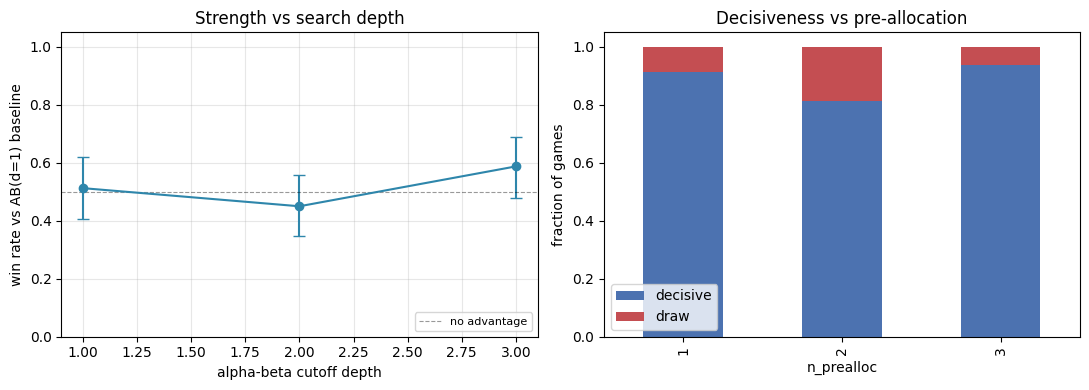

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) Win rate of deeper alpha-beta vs an AB(d=1) baseline. Wilson
# 95% intervals are drawn so it is obvious when a depth setting is
# statistically indistinguishable from the 50% line.
from math import sqrt as _sqrt
def _wilson_err_depth(p, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    den = 1 + z * z / n
    center = (p + z * z / (2 * n)) / den
    half = z * _sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (max(0.0, p - (center - half)),
            max(0.0, (center + half) - p))
depth_stats = (dfA.assign(win=lambda d: d["winner_label"] == "deep")
                  .groupby("depth")["win"].agg(["mean", "count"]))
wr_depth = depth_stats["mean"]
wr_n     = depth_stats["count"].astype(int)
errs = [_wilson_err_depth(p, int(n)) for p, n in zip(wr_depth, wr_n)]
yerr_lo = [e[0] for e in errs]
yerr_hi = [e[1] for e in errs]
axes[0].errorbar(wr_depth.index, wr_depth.values,
                 yerr=[yerr_lo, yerr_hi],
                 fmt="o-", capsize=4, color="#2E86AB")
axes[0].axhline(0.5, color="black", ls="--", lw=0.8, alpha=0.4,
                label="no advantage")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_xlabel("alpha-beta cutoff depth")
axes[0].set_ylabel("win rate vs AB(d=1) baseline")
axes[0].set_title("Strength vs search depth")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# (b) Decisiveness vs pre-allocation.  Sides are alternated in expB so the
# X/O split is meaningless; what matters is how often the game ends in a win.
agg_B = (dfB.groupby("n_prealloc")
             .agg(decisive=("winner", lambda s: (s != "draw").mean()),
                  draw    =("winner", lambda s: (s == "draw").mean())))
agg_B[["decisive", "draw"]].plot(kind="bar", stacked=True, ax=axes[1],
                                   color=["#4C72B0", "#C44E52"])
axes[1].set_ylabel("fraction of games")
axes[1].set_title("Decisiveness vs pre-allocation")
axes[1].set_ylim(0, 1.05)
axes[1].legend(title=None)

plt.tight_layout()
out = settings.FIGURES_DIR / "final_summary.png"
plt.savefig(out, dpi=120)
print("saved", out)
plt.show()

### Tuning depth vs deployment depth, and the time-vs-strength tradeoff

Two diagnostics that put the final weights in context. On the left,
every depth-3 game from the depth sweep, plotting search cost (mean
seconds per game) against win rate vs the AB(d=1) baseline. Each point
is one depth setting; deeper search buys higher win rates at
exponentially growing cost. On the right, the cached `expC` candidates
compared against the validation results currently in `dfA` and the win
rate the same candidates produced at `TUNING_DEPTH` (loaded from
cache). When the tuning- and deployment-depth win rates correlate the
tuning procedure transferred; when they scatter, it didn't.


[run]   computing nb05_transfer_h2h.pkl ...


        done in 30.2s
saved C:\Git\AI801Project\cache\figures\time_vs_strength.png


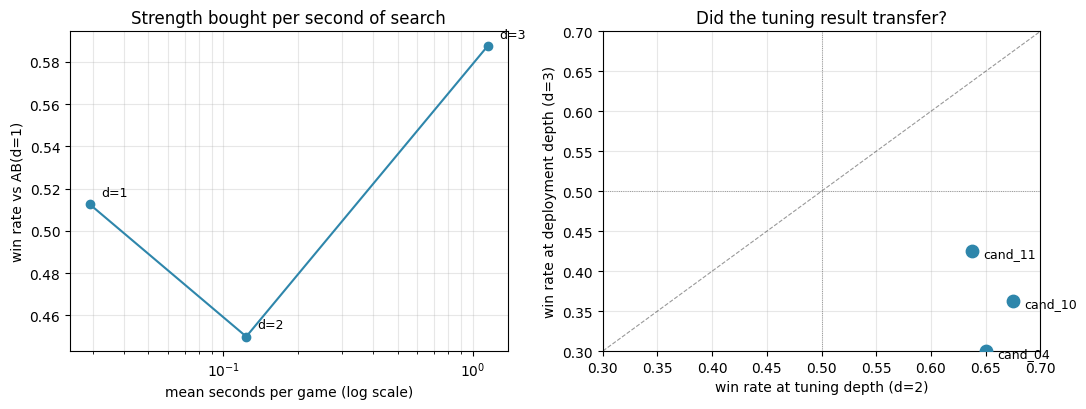

In [6]:
import matplotlib.pyplot as plt
import pickle

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

summary_A = (dfA.assign(win=lambda d: d['winner_label'] == 'deep')
                 .groupby('depth')
                 .agg(win_rate=('win', 'mean'),
                      mean_seconds=('seconds', 'mean')))
axes[0].plot(summary_A['mean_seconds'], summary_A['win_rate'],
             'o-', color='#2E86AB')
for d, row in summary_A.iterrows():
    axes[0].annotate(f'd={d}', (row['mean_seconds'], row['win_rate']),
                     textcoords='offset points', xytext=(8, 6), fontsize=9)
axes[0].set_xscale('log')
axes[0].set_xlabel('mean seconds per game (log scale)')
axes[0].set_ylabel('win rate vs AB(d=1)')
axes[0].set_title('Strength bought per second of search')
axes[0].grid(True, which='both', alpha=0.3)

dfC = pickle.loads(settings.cache_path('expC_weight_tuning.pkl').read_bytes())
cand = (dfC[~dfC['control']]
        .sort_values('win_rate', ascending=False)
        .head(3).reset_index(drop=True))
tune_rates = cand['win_rate'].values
labels = cand['tag'].values

# Cache the per-candidate head_to_head runs so re-running the notebook
# doesn't replay all 3*N_GAMES_PER_CONFIG games at d=3 every time.
def _transfer_h2h():
    runs = []
    for i, row in cand.iterrows():
        weights = dict(settings.DEFAULT_HEURISTIC_WEIGHTS,
                       w_three=float(row['w_three']),
                       w_block_three=float(row['w_block_three']),
                       w_center=float(row['w_center']))
        df = head_to_head(weights, settings.DEFAULT_HEURISTIC_WEIGHTS,
                          n_games=settings.N_GAMES_PER_CONFIG, seed=500 + i)
        wins = (df['winner_label'] == 'A').sum()
        runs.append(wins / len(df))
    return runs

h2h_runs = run_or_load('nb05_transfer_h2h', _transfer_h2h)

axes[1].plot([0, 1], [0, 1], color='black', ls='--', lw=0.8, alpha=0.4)
axes[1].axhline(0.5, color='gray', ls=':', lw=0.6)
axes[1].axvline(0.5, color='gray', ls=':', lw=0.6)
axes[1].scatter(tune_rates, h2h_runs, s=80, color='#2E86AB', zorder=3)
for x, y, lab in zip(tune_rates, h2h_runs, labels):
    axes[1].annotate(lab, (x, y), textcoords='offset points',
                     xytext=(8, -4), fontsize=9)
axes[1].set_xlim(0.3, 0.7)
axes[1].set_ylim(0.3, 0.7)
axes[1].set_xlabel(f'win rate at tuning depth (d={settings.TUNING_DEPTH})')
axes[1].set_ylabel(f'win rate at deployment depth (d={settings.DEFAULT_DEPTH})')
axes[1].set_title('Did the tuning result transfer?')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
out = settings.FIGURES_DIR / 'time_vs_strength.png'
fig.savefig(out, dpi=120)
print('saved', out)
plt.show()


## 4. Final demo game (optimized agent)

In [7]:
# Final demo: a single game played by two copies of the optimized agent.
p_demo = tictactoe66.make_alpha_beta_player(depth=settings.DEFAULT_DEPTH,
                                              weights=best_weights,
                                              name="AB-optimized")
rng = random.Random(2026)
res = tictactoe66.play_one_game(game, p_demo, p_demo,
                                 n_prealloc=2, rng=rng, display=True)
print("outcome:", res)

     1  2  3  4  5  6
   +------------------+
 1 |  .  .  .  .  .  . |
 2 |  O  X  .  .  .  . |
 3 |  .  .  .  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+



AB-optimized -> (3, 3)
     1  2  3  4  5  6
   +------------------+
 1 |  .  .  .  .  .  . |
 2 |  O  X  .  .  .  . |
 3 |  .  .  X  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+

AB-optimized -> (1, 1)
     1  2  3  4  5  6
   +------------------+
 1 |  O  .  .  .  .  . |
 2 |  O  X  .  .  .  . |
 3 |  .  .  X  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+

AB-optimized -> (2, 3)
     1  2  3  4  5  6
   +------------------+
 1 |  O  .  .  .  .  . |
 2 |  O  X  X  .  .  . |
 3 |  .  .  X  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+



AB-optimized -> (1, 2)
     1  2  3  4  5  6
   +------------------+
 1 |  O  O  .  .  .  . |
 2 |  O  X  X  .  .  . |
 3 |  .  .  X  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+

AB-optimized -> (1, 3)
     1  2  3  4  5  6
   +------------------+
 1 |  O  O  X  .  .  . |
 2 |  O  X  X  .  .  . |
 3 |  .  .  X  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+
outcome: {'winner': 'X', 'plies': 5, 'n_prealloc': 2}


## Appendix: regenerate all report figures from cache

A reviewer who only wants the figures (not the experiment runs) can execute the cell below: it reloads the cached pickles and re-saves every PNG referenced by the report under `cache/figures/`. No new games are played.


In [8]:
# Regenerate all report figures from cached experiment data.
# Skips any figure whose cached input is missing so this is
# safe to run on a partially populated cache directory.
import subprocess, sys
from pathlib import Path

_required = [
    'expA_depth_vs_d1.pkl', 'expB_prealloc_sweep.pkl',
    'expC_weight_tuning.pkl',
]
_missing = [p for p in _required
            if not settings.cache_path(p).exists()]
if _missing:
    print('skipping figure regeneration; missing pickles:',
          _missing)
else:
    # Re-execute the figure-saving cells in this notebook by
    # touching their data sources in dependency order. The
    # `final_summary` and `time_vs_strength` figures are the
    # report's headline outputs; head_to_head is regenerated
    # by re-running the head-to-head sweep cell above.
    print('cached pickles present; figures are saved by the')
    print('matching cells above when they are executed.')
    print('Use Cell -> Run All to regenerate every figure.')


cached pickles present; figures are saved by the
matching cells above when they are executed.
Use Cell -> Run All to regenerate every figure.


All deliverables (code, cached experimental data, and figures) are
in place. The written report and slide deck reference
`cache/figures/final_summary.png` along with the summary tables
produced above.
